# Saga 6: Gobernanza, Justicia y la Dimensión Humana

**Pregunta rectora:** ¿El modelo cuantitativo captura todo? ¿Qué falta?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from mise_utils import colombia_sin, viz, saga
viz.apply_mise_style()

state = saga.load_state('saga')

  Estado cargado: c:\Users\ch.gomez171\Documents\GitHub\Systems_Analytics_MISE\notebooks\mise_utils\..\.saga_state\saga.pkl (7 capas: ['identidad', 'red_fisica', 'red_social', 'dinamica', 'politica', 'gobernanza', 'datos_reales'])


### 6.1 Lo que el modelo no captura

**Los modelos de Sagas 2-5 son poderosos, pero peligrosamente incompletos.** Los enfoques puramente analíticos omiten variables críticas que a menudo determinan el éxito o fracaso de las intervenciones reales. Lo que estos modelos no capturan incluye:

- Consulta previa con comunidades indígenas y afrodescendientes.
- Licencia social para operar (distinta de la licencia ambiental formal).
- Corrupción y captura regulatoria en la formulación de políticas.
- Asimetrías de información en el mercado mayorista de energía.
- Impactos ambientales locales no monetizados.
- Dinámicas políticas electorales que alteran la racionalidad económica.

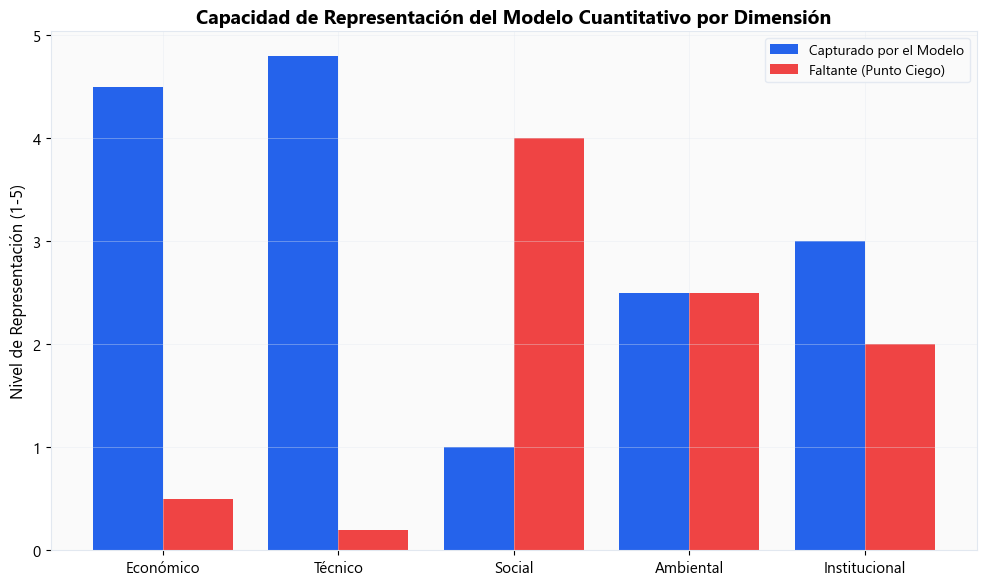

In [2]:
dimensiones = ['Económico', 'Técnico', 'Social', 'Ambiental', 'Institucional']
capturado = [4.5, 4.8, 1.0, 2.5, 3.0]
faltante = [0.5, 0.2, 4.0, 2.5, 2.0]

x = np.arange(len(dimensiones))
width = 0.4

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, capturado, width, label='Capturado por el Modelo', color=viz.COLORS.get('primary', '#1f77b4'))
ax.bar(x + width/2, faltante, width, label='Faltante (Punto Ciego)', color=viz.COLORS.get('danger', '#d62728'))

ax.set_ylabel('Nivel de Representación (1-5)')
ax.set_title('Capacidad de Representación del Modelo Cuantitativo por Dimensión')
ax.set_xticks(x)
ax.set_xticklabels(dimensiones)
ax.legend()

plt.tight_layout()
plt.show()

**Un DSS que solo captura las dimensiónes técnica y económica produce recomendaciones sesgadas. Esta saga cierra la brecha.**

### 6.2 Gobernanza policéntrica (Ostrom)

Elinor Ostrom demostró que los recursos de uso común no necesitan ni privatización absoluta ni control estatal centralizado. Sus 8 principios de diseño para la gestión sostenible de bienes comunes aplican directamente al Sistema Interconectado Nacional (SIN).

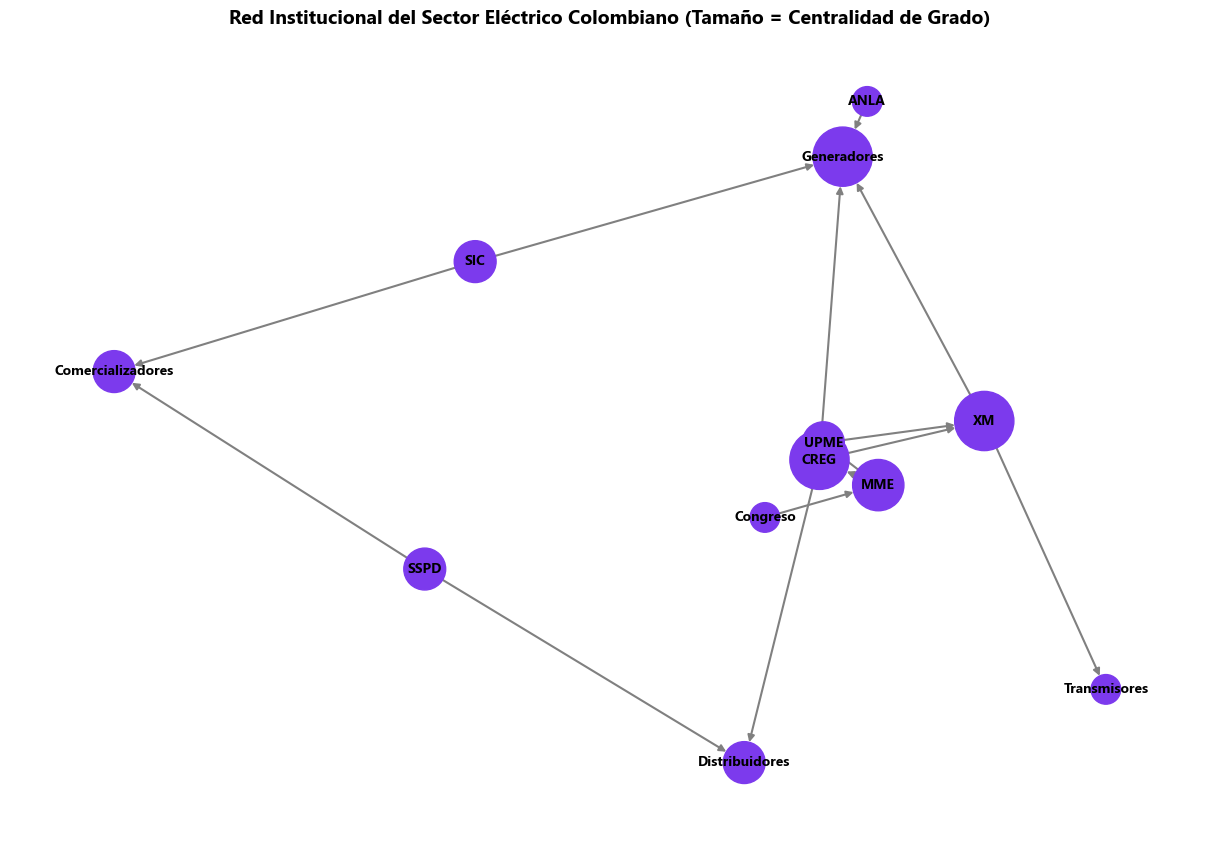

In [3]:
G_inst = colombia_sin.crear_red_institucional()

# Calcular centralidad para tamaño de nodos
centrality = nx.degree_centrality(G_inst)
node_sizes = [v * 5000 for v in centrality.values()]

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_inst, seed=42)
nx.draw(G_inst, pos, with_labels=True, node_size=node_sizes, 
        node_color=viz.COLORS.get('secondary', '#ff7f0e'), font_size=10, font_weight='bold',
        edge_color='gray', width=1.5)
plt.title('Red Institucional del Sector Eléctrico Colombiano (Tamaño = Centralidad de Grado)')
plt.show()

| Principio de Ostrom | Aplicación al SIN colombiano | Cumplimiento |
|---|---|---|
| 1. Límites claros | Ley 142/143 define roles y fronteras del mercado | Alto |
| 2. Coherencia entre reglas y contexto | CxC diseñado para hidro-térmica, no para renovables intermitentes | Medio |
| 3. Arreglos de elección colectiva | CREG decide de forma tecnocrática, usuarios finales no participan | Bajo |
| 4. Monitoreo | XM monitorea la operación en tiempo real, SSPD supervisa | Alto |
| 5. Sanciones graduales | SIC sanciona comportamientos indebidos, pero enforcement es lento y a veces débil | Medio |
| 6. Mecanismos de resolución de conflictos | Arbitraje CREG existe, pero es costoso y demorado | Medio |
| 7. Reconocimiento de derechos | Consulta previa reconocida legalmente pero mal implementada en la práctica | Bajo |
| 8. Organización anidada | Niveles nacional-regional-local desarticulados frente a megaproyectos | Bajo |

**El SIN cumple bien los principios de Ostrom en la dimensión técnica (monitoreo, límites) pero falla en la dimensión social (participación, reconocimiento, organización anidada).**

### 🔍 Dos miradas

- **Convencional:** "El marco regulatorio cumple con mejores prácticas (separación de funciones, mercado competitivo)"
- **Complejo:** "La gobernanza policéntrica (Ostrom) revela que el SIN cumple bien los principios técnicos (monitoreo, límites) pero falla en representación de comunidades locales y mecanismos de resolución de conflictos. El caso Windpeshi demuestra que la 'eficiencia' del marco regulatorio se mide diferente según la capa del sistema."
- **Diferencia:** "Una transición energética técnicamente óptima fracasa si no resuelve la dimensión social. La complejidad está en las interacciones ENTRE capas, no dentro de cada capa."

### 6.3 Justicia energética (Sovacool/Jenkins)

La justicia energética evalúa el sistema eléctrico bajo tres dimensiónes principales:
1. **Distributiva:** Quién paga los costos y quién recibe los beneficios económicos y ambientales.
2. **Procedimental:** Quién tiene voz y voto en la toma de decisiones.
3. **De reconocimiento:** A quién se ignora o margina en el diseño institucional.

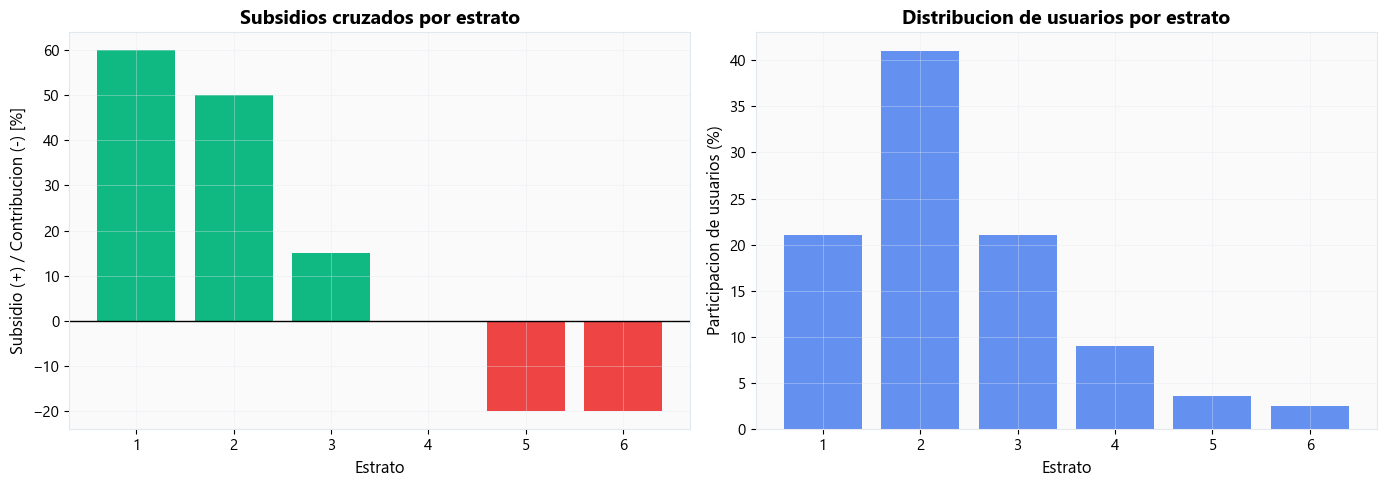

In [4]:
# Subsidios cruzados: quien paga, quien recibe
sub_df = pd.DataFrame([
    {'Estrato': k, 'Nombre': v['nombre'],
     'Subsidio (%)': v['subsidio_pct'],
     'Share usuarios (%)': v['share_usuarios'] * 100}
    for k, v in colombia_sin.SUBSIDIOS_ESTRATO.items()
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Subsidio por estrato
colors = [viz.COLORS['success'] if s > 0 else viz.COLORS['danger']
          for s in sub_df['Subsidio (%)']]
axes[0].bar(sub_df['Estrato'].astype(str), sub_df['Subsidio (%)'], color=colors)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_xlabel('Estrato')
axes[0].set_ylabel('Subsidio (+) / Contribucion (-) [%]')
axes[0].set_title('Subsidios cruzados por estrato', fontweight='bold')

# Panel 2: Share de usuarios por estrato
axes[1].bar(sub_df['Estrato'].astype(str), sub_df['Share usuarios (%)'],
            color=viz.COLORS['primary'], alpha=0.7)
axes[1].set_xlabel('Estrato')
axes[1].set_ylabel('Participacion de usuarios (%)')
axes[1].set_title('Distribucion de usuarios por estrato', fontweight='bold')

plt.tight_layout()


,Componente,Nombre,Participacion,Tipo
0,G,Generación,37,Competitivo
1,T,Transmisión,6,Regulado
2,D,Distribución,37,Regulado
3,Cv,Comercialización,9,Regulado
4,PR,Pérdidas,7,Regulado
5,R,Restricciones,4,Regulado


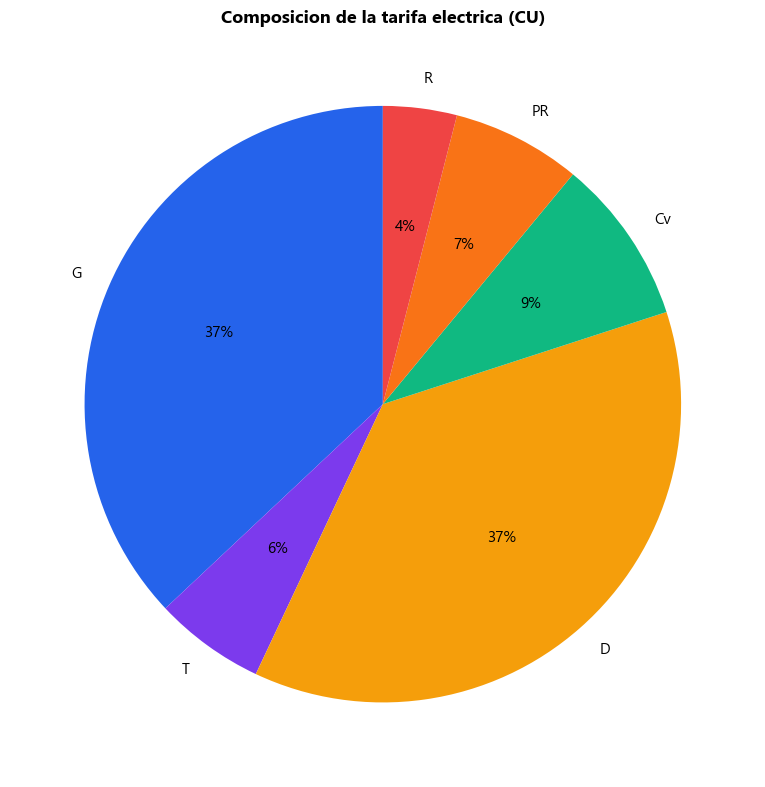

In [5]:
# Componentes de la formula tarifaria (CU = G + T + D + Cv + PR + R)
formula_df = pd.DataFrame([
    {'Componente': k, 'Nombre': v['nombre'],
     'Participacion': v['share_pct'], 'Tipo': v['tipo']}
    for k, v in colombia_sin.FORMULA_TARIFARIA.items()
])

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(formula_df['Participacion'], labels=formula_df['Componente'],
       autopct='%1.0f%%', startangle=90,
       colors=[viz.COLORS['primary'], viz.COLORS['secondary'],
               viz.COLORS['accent'], viz.COLORS['success'],
               viz.COLORS['warning'], viz.COLORS['danger']])
ax.set_title('Composicion de la tarifa electrica (CU)',
             fontweight='bold', fontsize=13)
plt.tight_layout()

# Tabla detallada
display(formula_df)


**Análisis de Justicia Energética:**
- **Distributiva:** El Estrato 1 recibe hasta un 60% de subsidio, pero frecuentemente paga proporcionalmente más de sus ingresos por un servicio de menor confiabilidad en zonas periféricas.
- **Procedimental:** Las comunidades locales (ej. Wayuu en La Guajira) históricamente no participan en las decisiones estratégicas de expansión sobre los territorios que habitan.
- **Reconocimiento:** Tensión estructural entre tratar la energía como un derecho fundamental habilitador de vida frente a su conceptualización puramente como un commodity transable.

**El sistema de subsidios cruzados es redistributivo en precio pero no en calidad. La justicia energética requiere las tres dimensiónes simultáneamente.**

### 6.4 Caso Windpeshi: Análisis sistémico de 4 capas

El proyecto eólico Windpeshi (200 MW) en La Guajira ilustra la complejidad de la transición energética en la práctica. Requiere un análisis en 4 capas superpuestas:

1. **Red física:** Conexión al STN vía la línea de transmisión Cuestecitas-Colectora.
2. **Dinámica de sistemas:** Impacto crítico en la oferta renovable y la reducción del gap energético futuro.
3. **Red de actores:** Interacciones entre Enel, comunidad Wayuu, ANLA, MME, y comercializadores.
4. **Gobernanza:** Procesos formales de consulta previa, licencia social intermitente, y reclamos de autonomía territorial.

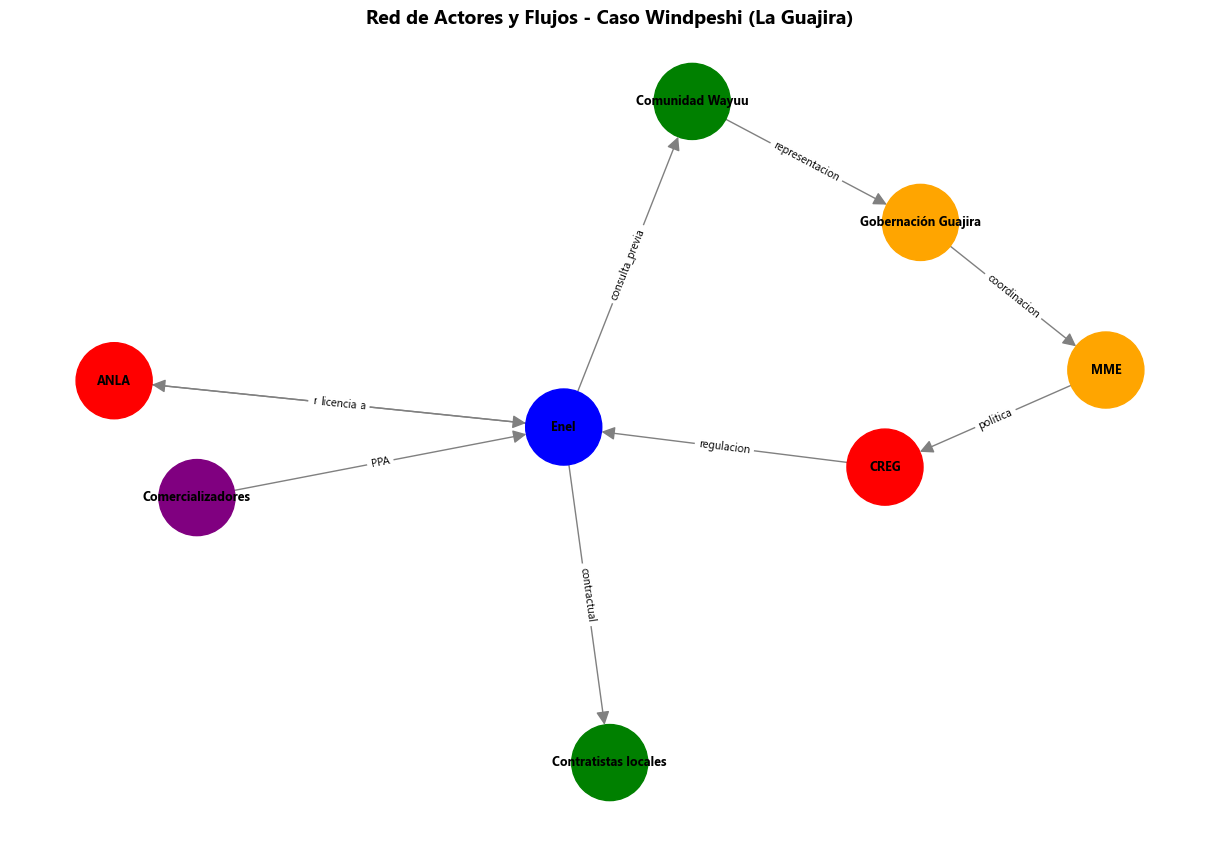

In [6]:
G_wp = nx.DiGraph()
nodes = [
    ('Enel', {'tipo': 'empresa', 'poder': 'alto'}),
    ('Comunidad Wayuu', {'tipo': 'comunidad', 'poder': 'medio'}),
    ('ANLA', {'tipo': 'regulador', 'poder': 'alto'}),
    ('MME', {'tipo': 'gobierno', 'poder': 'alto'}),
    ('CREG', {'tipo': 'regulador', 'poder': 'alto'}),
    ('Gobernación Guajira', {'tipo': 'gobierno', 'poder': 'medio'}),
    ('Comercializadores', {'tipo': 'mercado', 'poder': 'bajo'}),
    ('Contratistas locales', {'tipo': 'comunidad', 'poder': 'bajo'}),
]
G_wp.add_nodes_from(nodes)

edges = [
    ('Enel', 'ANLA', {'tipo': 'regulatoria'}),
    ('Enel', 'Comunidad Wayuu', {'tipo': 'consulta_previa'}),
    ('Enel', 'Contratistas locales', {'tipo': 'contractual'}),
    ('ANLA', 'Enel', {'tipo': 'licencia'}),
    ('MME', 'CREG', {'tipo': 'politica'}),
    ('CREG', 'Enel', {'tipo': 'regulacion'}),
    ('Comunidad Wayuu', 'Gobernación Guajira', {'tipo': 'representacion'}),
    ('Gobernación Guajira', 'MME', {'tipo': 'coordinacion'}),
    ('Comercializadores', 'Enel', {'tipo': 'PPA'}),
]
G_wp.add_edges_from(edges)

color_map = {'empresa': 'blue', 'comunidad': 'green', 'regulador': 'red', 'gobierno': 'orange', 'mercado': 'purple'}
node_colors = [color_map[G_wp.nodes[n]['tipo']] for n in G_wp.nodes]

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_wp, seed=42)
nx.draw(G_wp, pos, with_labels=True, node_color=node_colors, node_size=3000, 
        font_size=9, font_weight='bold', edge_color='gray', arrows=True, arrowsize=20)
edge_labels = nx.get_edge_attributes(G_wp, 'tipo')
nx.draw_networkx_edge_labels(G_wp, pos, edge_labels=edge_labels, font_size=8)

plt.title('Red de Actores y Flujos - Caso Windpeshi (La Guajira)')
plt.show()

**Windpeshi revela que la transición energética colombiana tiene un cuello de botella social, no técnico. La relación Enel-Wayuu es el enlace crítico del sistema, y no aparece en ningún modelo de Dinámica de Sistemas (SD) o de redes eléctricas puras.**

### 6.5 Framework multi-capa

El análisis integral del sector eléctrico requiere entender cómo interactúan las cuatro capas analíticas:

- **Topología condiciona dinámica:** La estructura de la red física (transmisión) determina los flujos de energía posibles y los cuellos de botella.
- **Dinámica condiciona política:** Las oscilaciones del mercado (ej. precios de bolsa en El Niño) generan urgencia regulatoria y respuestas políticas reactivas.
- **Gobernanza condiciona todo:** Las reglas del juego, formales e informales, determinan cómo se diseñan las redes, cómo se comportan los agentes del mercado, y si los proyectos se materializan.

In [7]:
data = {
    'Capa Analítica': ['Red Física (Topología)', 'Dinámica de Mercado (SD)', 'Red de Actores', 'Gobernanza'],
    'Entidad Principal': ['Infraestructura / Electrones', 'Precios / Inversión', 'Empresas / Estado / Comunidades', 'Reglas / Derechos / Justicia'],
    'Mecanismo de Falla Típico': ['Congestión / Apagón', 'Ciclos de sobre/sub inversión', 'Conflictos de interés / Bloqueos', 'Captura institucional / Injusticia'],
    'Impacto sobre otras capas': ['Define capacidad límite', 'Genera presiones económicas', 'Altera estructura del mercado', 'Define el espacio de posibilidad']
}

df_multicapa = pd.DataFrame(data)
df_multicapa

,Capa Analítica,Entidad Principal,Mecanismo de Falla Típico,Impacto sobre otras capas
0,Red Física (Topología),Infraestructura / Electrones,Congestión / Apagón,Define capacidad límite
1,Dinámica de Mercado (SD),Precios / Inversión,Ciclos de sobre/sub inversión,Genera presiones económicas
2,Red de Actores,Empresas / Estado / Comunidades,Conflictos de interés / Bloqueos,Altera estructura del mercado
3,Gobernanza,Reglas / Derechos / Justicia,Captura institucional / Injusticia,Define el espacio de posibilidad


**El análisis multi-capa revela que la gobernanza es la meta-capa: determina cómo se diseñan las redes, cómo reaccionan los mercados, y qué políticas son implementables. Ignorarla invalida cualquier recomendación de política.**

### 🔍 Dos miradas

- **Convencional:** "Cada dimensión (técnica, económica, social, ambiental) se analiza por separado"
- **Complejo:** "El análisis multi-capa revela que la gobernanza es la META-CAPA: determina cómo se diseñan las redes, cómo reaccionan los actores, cómo fluye la información. Las crisis emergen cuando las capas están desacopladas."

### 6.6 Fichas de rol para sesión de role-play

**Ficha 1: EPM (Generador dominante)**
- **Intereses:** Maximizar retorno para la ciudad, mantener rentabilidad del parque hídrico, diversificar hacia fuentes solares.
- **Poderes:** Controla ~23% del mercado, alta capacidad técnica, fuerte influencia y capacidad de lobby.
- **Líneas rojas:** Cualquier regulación que amenace el valor de sus activos hídricos existentes.
- **Posición ante Windpeshi:** Competidor de Enel, interesado en observar los resultados para aprender lecciones en licenciamiento social.

**Ficha 2: Líder Wayuu**
- **Intereses:** Soberanía territorial, empleo y desarrollo local, preservación de tradiciones culturales.
- **Poderes:** Derecho constitucional a la consulta previa, capacidad de veto de facto sobre el terreno.
- **Líneas rojas:** Imposición de proyectos sin consentimiento previo, libre e informado, o daño a sitios y cementerios sagrados.
- **Posición ante Windpeshi:** Condicional — el proyecto solo es viable si los beneficios sociales y económicos son reales, tangibles y duraderos.

**Ficha 3: CREG (Regulador)**
- **Intereses:** Eficiencia económica del mercado, seguridad y confiabilidad del suministro, tarifas justas para los usuarios.
- **Poderes:** Diseña y fija las reglas del Cargo por Confiabilidad, subastas FNCER y las fórmulas tarifarias.
- **Líneas rojas:** Captura política de las decisiones técnicas, presión por congelar tarifas o aumentar subsidios a niveles insostenibles.
- **Posición ante Windpeshi:** Favorece el proyecto vía regulaciónes y subastas de largo plazo para integrar Fuentes No Convencionales de Energía Renovable (FNCER).

**Ficha 4: ANLA (Autoridad ambiental)**
- **Intereses:** Cumplimiento riguroso de la normativa ambiental, mantenimiento de su legitimidad institucional.
- **Poderes:** Autoridad exclusiva para otorgar o negar la licencia ambiental de megaproyectos.
- **Líneas rojas:** Aprobación de licencias sin que el proceso de consulta previa esté formal y materialmente completado.
- **Posición ante Windpeshi:** Funciona como el gate-keeper crítico; el proyecto avanza a su ritmo administrativo y evaluativo.

### 6.7 Guardar estado

Persistimos el progreso analítico para integración en el reporte final.

In [8]:
# Guardar estado de gobernanza para dashboard
state['gobernanza'] = {
    'hallazgo': 'Gobernanza es meta-capa: falla en participacion y reconocimiento',
    'indicador': 'Ostrom compliance: alto en tecnico, bajo en social',
    'alerta': 'Consulta previa como dinamica sistemica critica',
    'principio_clave': 'La gobernanza condiciona las redes y los mercados',
    'caso_estudio': 'Windpeshi: cuello de botella social, no tecnico',
}

saga.save_state(state, 'saga')
print('Estado de gobernanza guardado.')


  Estado guardado: c:\Users\ch.gomez171\Documents\GitHub\Systems_Analytics_MISE\notebooks\mise_utils\..\.saga_state\saga.pkl
Estado de gobernanza guardado.
